# Phase 1.6 — Multi-mode chromatography & gradient elution

The mechanistic column model now covers the distinct downstream unit operations of a real
process-characterization campaign, all through **one transport-dispersive engine** whose
mode is set by the **isotherm law**:

| Mode | Modulator | Binding law | Elutes by |
|---|---|---|---|
| Cation / anion exchange (CEX/AEX) | salt (mM) | Steric-Mass-Action $b\propto(\Lambda/m)^{\nu}$ | **increasing** salt |
| HIC (salting-out) | salt (mM) | $b\propto e^{K_s m}$ | **decreasing** salt |
| RP-HPLC (linear solvent strength) | organic fraction $\phi$ | $b\propto e^{-S\phi}$ | **increasing** $\phi$ |

The engine carries the bound phase $q$ explicitly with a linear-driving-force term, so the
inlet modulator can change **linearly in time** — i.e. gradient elution — and multiple
components compete for a finite capacity (overload). We exercise each mode below.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

from downstream_doe.models import chromatography as chrom

GEOM = chrom.ColumnGeometry(length=0.1, diameter=0.01, porosity=0.4)
VELOCITY, DISPERSION = 1e-3, 1e-7


def plot_run(result, ax, *, mod_label, title, names=None):
    """Overlay outlet chromatogram(s) with the outlet modulator trace."""
    t_min = result.t / 60.0
    for i in range(result.c_outlet.shape[0]):
        label = names[i] if names else f'component {i+1}'
        ax.plot(t_min, result.c_outlet[i], label=label)
    ax.set_xlabel('time (min)'); ax.set_ylabel('outlet conc. (g/L)')
    ax.set_title(title)
    axm = ax.twinx()
    axm.plot(t_min, result.m_outlet, '--', color='grey', lw=1)
    axm.set_ylabel(mod_label, color='grey')
    ax.legend(loc='upper left', fontsize=8)
    return ax

## 1 — Ion exchange (CEX): salt gradient elution

A protein is loaded and washed at low salt (strong binding), then a **linear salt gradient**
sweeps it off. Steeper isotherm charge $\nu$ → sharper salt sensitivity → the band focuses
and elutes at a characteristic salt concentration.

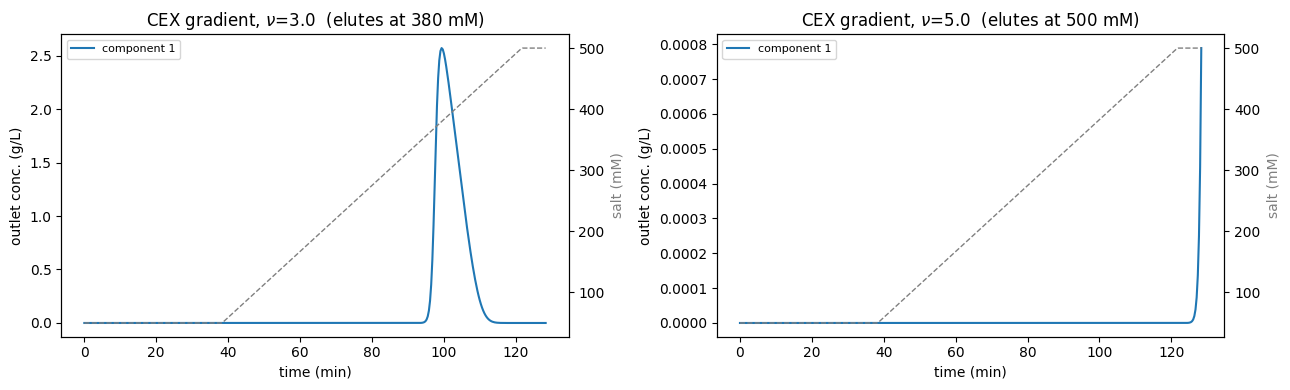

In [2]:
def cex_gradient(nu, m_end=500.0, gradient_cv=20.0, load=8.0):
    iso = chrom.cation_exchange(beta=[5e-3], nu=[nu], q_max=120.0, nu_ph=0.0)
    inj = chrom.Injection.from_load_density(load, [1.0], GEOM.porosity)
    program = chrom.ElutionProgram.linear_gradient(
        inj, m_start=50.0, m_end=m_end, gradient_cv=gradient_cv)
    setup = chrom.ColumnSetup(GEOM, VELOCITY, DISPERSION, iso, program, ph=7.0, n_cells=100)
    return chrom.run_column(setup)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for nu, ax in zip([3.0, 5.0], axes):
    res = cex_gradient(nu)
    mom = chrom.peak_moments(res.t, res.c_outlet[0])
    salt_apex = float(np.interp(mom['apex_time'], res.t, res.m_outlet))
    plot_run(res, ax, mod_label='salt (mM)',
             title=f'CEX gradient, $\\nu$={nu}  (elutes at {salt_apex:.0f} mM)')
fig.tight_layout()

## 2 — CEX vs AEX: opposite pH behaviour

Both are Steric-Mass-Action ion exchangers; they differ only in the **sign of the pH term**.
A cation exchanger binds more strongly as pH falls (protein more positive); an anion
exchanger binds more strongly as pH rises.

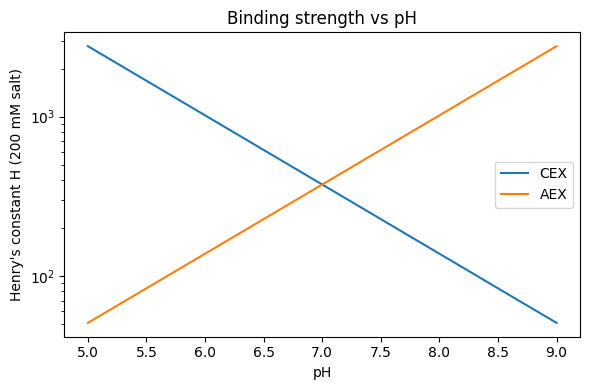

In [3]:
ph_axis = np.linspace(5.0, 9.0, 50)
cex = chrom.cation_exchange(beta=[5e-3], nu=[4.0], q_max=120.0)
aex = chrom.anion_exchange(beta=[5e-3], nu=[4.0], q_max=120.0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(ph_axis, [float(cex.henry(200.0, p)[0]) for p in ph_axis], label='CEX')
ax.semilogy(ph_axis, [float(aex.henry(200.0, p)[0]) for p in ph_axis], label='AEX')
ax.set_xlabel('pH'); ax.set_ylabel("Henry's constant H (200 mM salt)")
ax.set_title('Binding strength vs pH'); ax.legend(); fig.tight_layout()

## 3 — HIC: salting-out, eluted by a *decreasing* salt gradient

In hydrophobic-interaction chromatography binding **grows** with salt, so the protein is
loaded at high salt and eluted by ramping salt **down** — the mirror image of ion exchange.

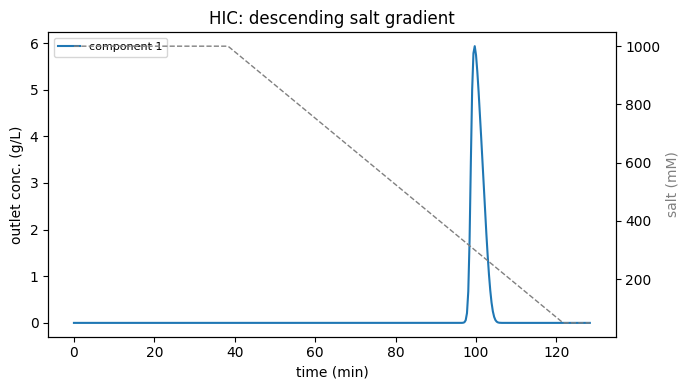

In [4]:
iso = chrom.hic(beta=[1e-3], ks=[0.012], q_max=120.0)
inj = chrom.Injection.from_load_density(8.0, [1.0], GEOM.porosity)
program = chrom.ElutionProgram.linear_gradient(
    inj, m_start=1000.0, m_end=50.0, gradient_cv=20.0)   # high -> low salt
res = chrom.run_column(chrom.ColumnSetup(GEOM, VELOCITY, DISPERSION, iso, program, n_cells=100))

fig, ax = plt.subplots(figsize=(7, 4))
plot_run(res, ax, mod_label='salt (mM)', title='HIC: descending salt gradient')
fig.tight_layout()

## 4 — RP-HPLC: reversed phase, eluted by rising organic fraction

The modulator is the organic fraction $\phi$ and retention follows linear-solvent-strength
theory, $\ln k = \ln k_w - S\phi$. The protein elutes as $\phi$ increases.

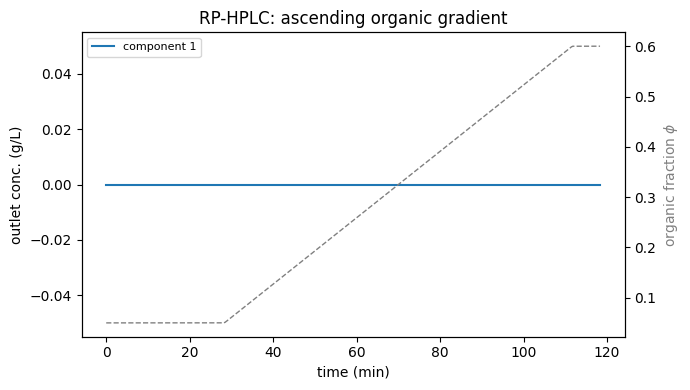

In [5]:
iso = chrom.reversed_phase(beta=[5e3], s=[25.0], q_max=120.0)
inj = chrom.Injection.from_load_density(4.0, [1.0], GEOM.porosity)
program = chrom.ElutionProgram.linear_gradient(
    inj, m_start=0.05, m_end=0.6, gradient_cv=20.0)       # 5% -> 60% organic
res = chrom.run_column(chrom.ColumnSetup(GEOM, VELOCITY, DISPERSION, iso, program, n_cells=100))

fig, ax = plt.subplots(figsize=(7, 4))
plot_run(res, ax, mod_label='organic fraction $\\phi$',
         title='RP-HPLC: ascending organic gradient')
fig.tight_layout()

## 5 — High-resolution IEX: resolving two species, and the gradient–resolution trade-off

With a nonlinear, competitive isotherm two closely-charged species ($\nu$ = 4.0 vs 4.3) are
co-loaded. A **shallow** gradient spreads their elution salts apart and resolves them; a
**steep** gradient co-elutes them. Resolution is computed from the peak moments.

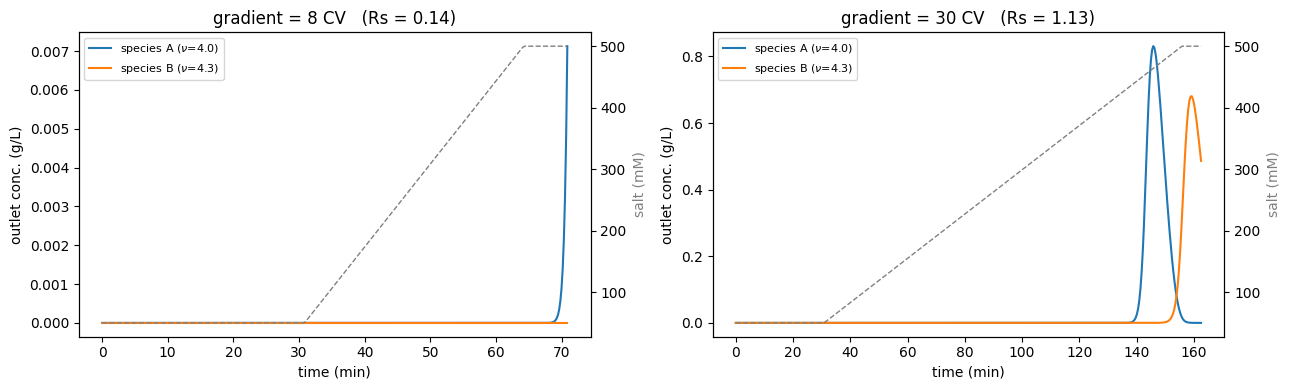

In [6]:
def two_component(gradient_cv):
    iso = chrom.high_resolution_iex(beta=[5e-3, 6e-3], nu=[4.0, 4.3], q_max=120.0, nu_ph=0.0)
    inj = chrom.Injection.from_load_density(5.0, [0.5, 0.5], GEOM.porosity)
    program = chrom.ElutionProgram.linear_gradient(
        inj, m_start=50.0, m_end=500.0, gradient_cv=gradient_cv)
    setup = chrom.ColumnSetup(GEOM, VELOCITY, DISPERSION, iso, program, mass_transfer=2.0, n_cells=120)
    return chrom.run_column(setup)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for gcv, ax in zip([8.0, 30.0], axes):
    res = two_component(gcv)
    rs = chrom.resolution(res.t, res.c_outlet[0], res.c_outlet[1])
    plot_run(res, ax, mod_label='salt (mM)',
             title=f'gradient = {gcv:.0f} CV   (Rs = {rs:.2f})',
             names=['species A ($\\nu$=4.0)', 'species B ($\\nu$=4.3)'])
fig.tight_layout()

## 6 — Overload (nonlinear capacity)

At low load the competitive isotherm reduces to the linear Henry slope; as the load rises the
finite capacity $q_{max}$ saturates and the apparent distribution $q^*/c$ drops — the source
of peak fronting/asymmetry in preparative chromatography.

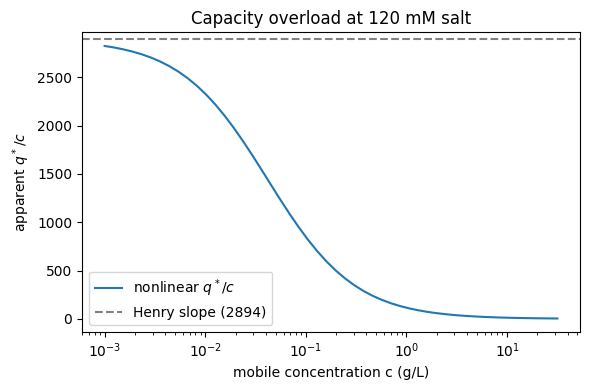

In [7]:
iso = chrom.cation_exchange(beta=[5e-3], nu=[4.0], q_max=120.0, nu_ph=0.0)
c_axis = np.logspace(-3, 1.5, 50)
henry = float(iso.henry(120.0, 7.0)[0])
q_over_c = [float(iso.q_star(np.array([c]), 120.0, 7.0)[0]) / c for c in c_axis]

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(c_axis, q_over_c, label='nonlinear $q^*/c$')
ax.axhline(henry, ls='--', color='grey', label=f"Henry slope ({henry:.0f})")
ax.set_xlabel('mobile concentration c (g/L)'); ax.set_ylabel('apparent $q^*/c$')
ax.set_title('Capacity overload at 120 mM salt'); ax.legend(); fig.tight_layout()